# 1. Pacakages required

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr

from datetime import datetime

# 2. Load the data

In [2]:
# For last 5 years:
end = datetime.now()
start = datetime(end.year - 5, end.month, end.day)


In [3]:
# Google Stocks
google = ['GOOG']
df_google = yf.download(google,start=start , end=end)

print(f"\n {len(df_google)}")
df_google.head()



/tmp/ipykernel_182/787151712.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_google = yf.download(google,start=start , end=end)
[*********************100%***********************]  1 of 1 completed


 1256


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2021-03-15,102.483116,102.511380,101.343471,102.275319,25962000
2021-03-16,103.774025,105.313389,102.657195,103.103035,29832000
2021-03-17,103.702606,104.629990,101.863700,102.956231,25980000
2021-03-18,100.981949,102.929960,100.849537,102.210866,27228000
2021-03-19,101.328110,101.819074,100.062499,101.271075,46298000


In [4]:
df_google.columns.values

array([('Close', 'GOOG'), ('High', 'GOOG'), ('Low', 'GOOG'),
       ('Open', 'GOOG'), ('Volume', 'GOOG')], dtype=object)

### Data Pre-processing:


In [5]:
# Fix the multiindex :
if isinstance(df_google.columns, pd.MultiIndex):
    df_google.columns = df_google.columns.get_level_values(0)

# Reset the 'Date' index:
if 'Date' not in df_google.columns:
    df_google.reset_index(inplace=True)

# Convert to datetime
df_google['Date'] = pd.to_datetime(df_google['Date'])

df_google.head()

Price,Date,Close,High,Low,Open,Volume
0,2021-03-15,102.483116,102.511380,101.343471,102.275319,25962000
1,2021-03-16,103.774025,105.313389,102.657195,103.103035,29832000
2,2021-03-17,103.702606,104.629990,101.863700,102.956231,25980000
3,2021-03-18,100.981949,102.929960,100.849537,102.210866,27228000
4,2021-03-19,101.328110,101.819074,100.062499,101.271075,46298000


In [6]:
print(f"\n size of the data = {len(df_google)}")

# NAN values per column
print(f"\n Number of null values per column---> ")
df_google.isnull().sum()


 size of the data = 1256

 Number of null values per column---> 


,0
Price,
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [7]:
df_google[['Close','High','Low','Open','Volume']].describe()

Price,Close,High,Low,Open,Volume
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,155.195347,156.903237,153.401547,155.087314,2.414047e+07
std,55.673109,56.299347,54.916726,55.647271,1.014659e+07
min,82.810135,85.845222,82.770460,84.813691,6.138200e+06
25%,119.158089,120.354647,118.171071,119.190458,1.761085e+07
50%,139.816368,141.025705,138.304205,139.534243,2.177370e+07
75%,172.061073,174.379144,170.040023,172.023957,2.741800e+07
max,344.657196,349.903504,338.351644,348.269676,9.779860e+07


# 3. Visualization

In [8]:
df=df_google.copy() # since the stock prices were changing.
df['Date'] = pd.to_datetime(df['Date'])
df.head(5)

Price,Date,Close,High,Low,Open,Volume
0,2021-03-15,102.483116,102.511380,101.343471,102.275319,25962000
1,2021-03-16,103.774025,105.313389,102.657195,103.103035,29832000
2,2021-03-17,103.702606,104.629990,101.863700,102.956231,25980000
3,2021-03-18,100.981949,102.929960,100.849537,102.210866,27228000
4,2021-03-19,101.328110,101.819074,100.062499,101.271075,46298000


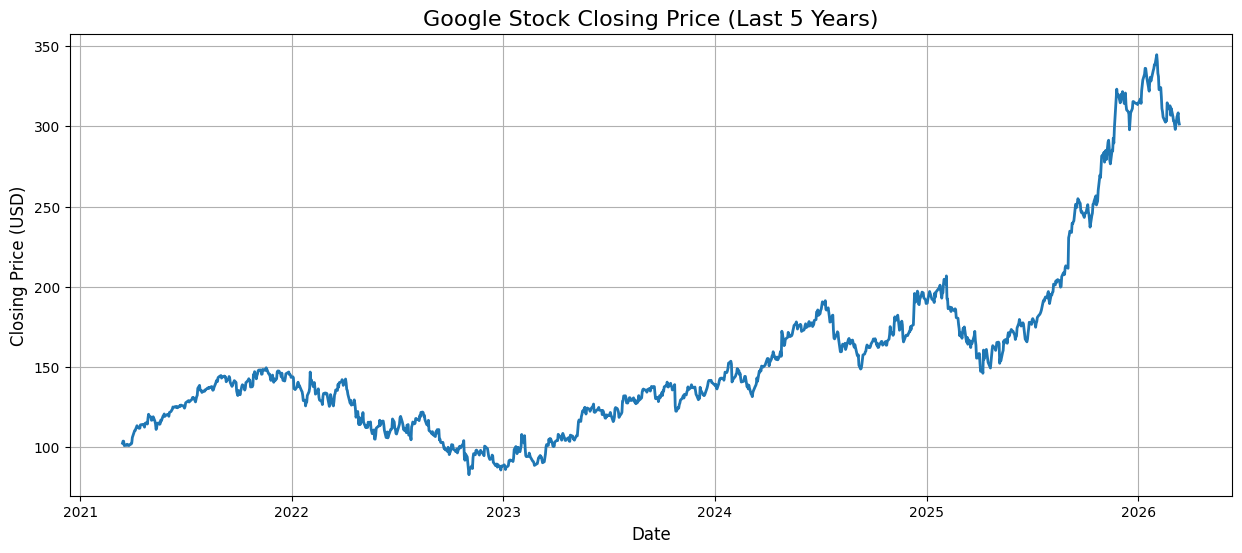

In [9]:
# 1. Historical view of the closing price

# Set Date as index (best practice for time series plotting):
df_google.set_index('Date', inplace=True)
# Plot:
plt.figure(figsize=(15,6))
plt.plot(df_google['Close'], linewidth=2)
plt.title('Google Stock Closing Price (Last 5 Years)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.grid(True)
plt.show()


- The historical closing price plot shows that Google's stock exhibits a clear long-term upward trend, interspersed with periods of decline and recovery. The mean price level changes over time, indicating that the series is non-stationary. Additionally, the magnitude of price fluctuations increases in later periods, suggesting volatility clustering. These characteristics confirm the presence of temporal structure and justify the use of time-series forecasting models. However, the non-stationary nature of the series suggests that transformations such as differencing may be necessary for statistical models like ARIMA.

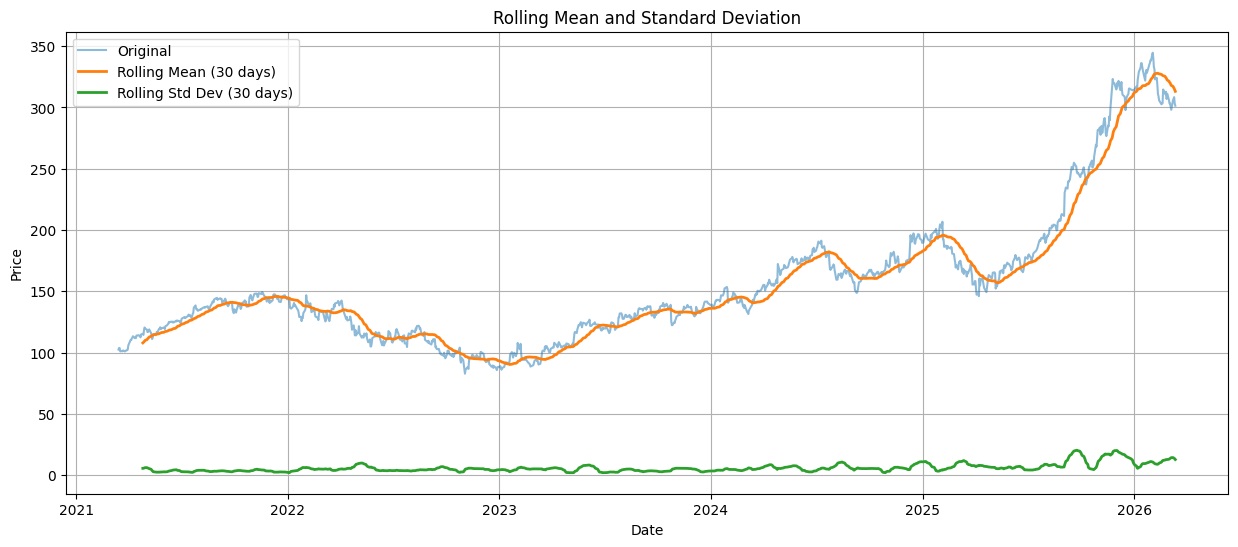

In [10]:
# 2. Rolling Mean and Rolling Standard Deviation

window = 30
df.set_index('Date', inplace=True)
rolling_mean = df['Close'].rolling(window).mean()
rolling_std = df['Close'].rolling(window).std()

plt.figure(figsize=(15,6))
plt.plot(df['Close'], label='Original', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean (30 days)', linewidth=2)
plt.plot(rolling_std, label='Rolling Std Dev (30 days)', linewidth=2)
plt.title('Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()


- The rolling mean and rolling standard deviation plot confirms that Google's stock price series is non-stationary. The rolling mean shows clear upward and downward trends over time, indicating that the average price level is not constant. Similarly, the rolling standard deviation increases during later periods, reflecting higher volatility. These observations demonstrate that both the mean and variance change over time, violating the assumptions of stationarity. As a result, statistical models such as ARIMA will require transformations like differencing, while machine learning and deep learning models such as XGBoost and LSTM can directly model this non-stationary behavior.

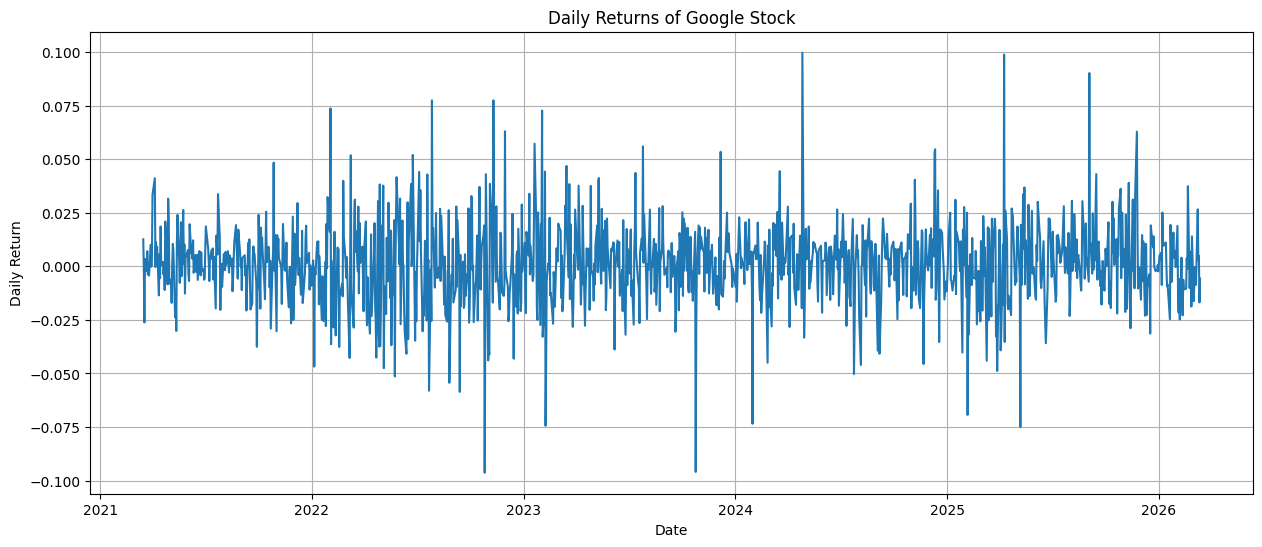

In [11]:
# 3. Daily Return Analysis:

df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(15,6))
plt.plot(df['Daily Return'])
plt.title('Daily Returns of Google Stock')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

- The daily returns plot shows that Google's stock returns fluctuate around zero without a clear trend, indicating that the returns are approximately stationary. This contrasts with the non-stationary behavior observed in the price series. Additionally, the plot reveals periods of increased volatility followed by calmer periods, a phenomenon known as volatility clustering. These characteristics are consistent with classical financial time series behavior. The apparent randomness of returns supports the use of the Random Walk model as a strong naïve baseline, while the presence of temporal patterns in volatility justifies the use of more advanced models such as ARIMA, XGBoost, and LSTM for forecasting.

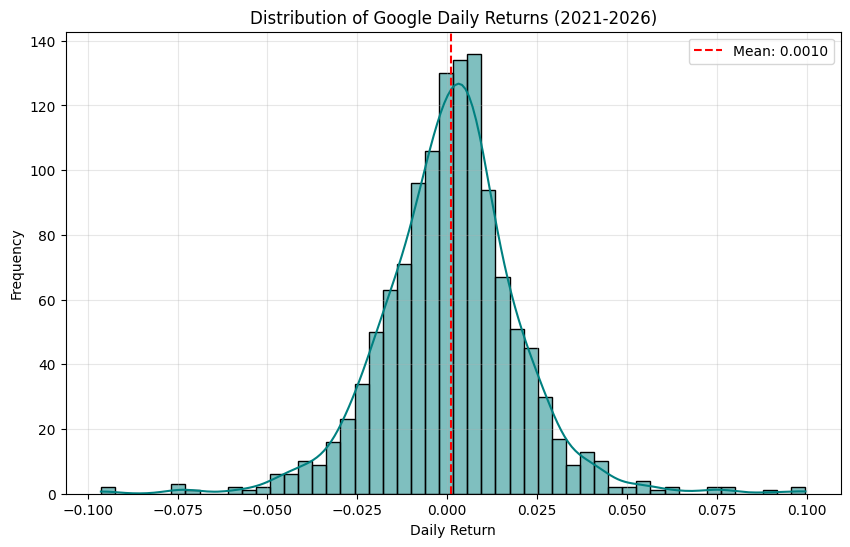

Skewness: 0.06
Kurtosis: 3.39


In [14]:
# 4. Are Returns Normally Distributed?

# Generate the Histogram and KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily Return'], bins=50, kde=True, color='teal')

# Add statistical markers
plt.axvline(df['Daily Return'].mean(), color='red', linestyle='--', label=f"Mean: {df['Daily Return'].mean():.4f}")
plt.title('Distribution of Google Daily Returns (2021-2026)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate higher-order moments for your report
print(f"Skewness: {df['Daily Return'].skew():.2f}")
print(f"Kurtosis: {df['Daily Return'].kurtosis():.2f}")

- The histogram illustrates that Google’s daily returns follow a Leptokurtic distribution, characterized by a sharp central peak and "fat tails". The high concentration of data points around the $0.00$ mean confirms that the series is stationary, which is a vital prerequisite for the Random Forest model to learn effectively. However, the presence of outliers stretching toward $\pm 0.10$ indicates that the stock experiences "extreme" market events more frequently than a standard normal distribution would predict, capturing the sudden volatility spikes seen in your earlier time-series plots.From a modeling perspective, this distribution justifies your shift away from simple linear regression toward an ensemble-based approach. Because the data is not perfectly Gaussian, the Random Forest Regressor is better equipped to handle these non-linear anomalies and "shocks" without being overly skewed by the extreme values in the tails. By centering the features on this stationary return data rather than the raw, trending price, the model can more accurately capture the underlying momentum and risk profiles of Alphabet Inc. over the observed five-year period.

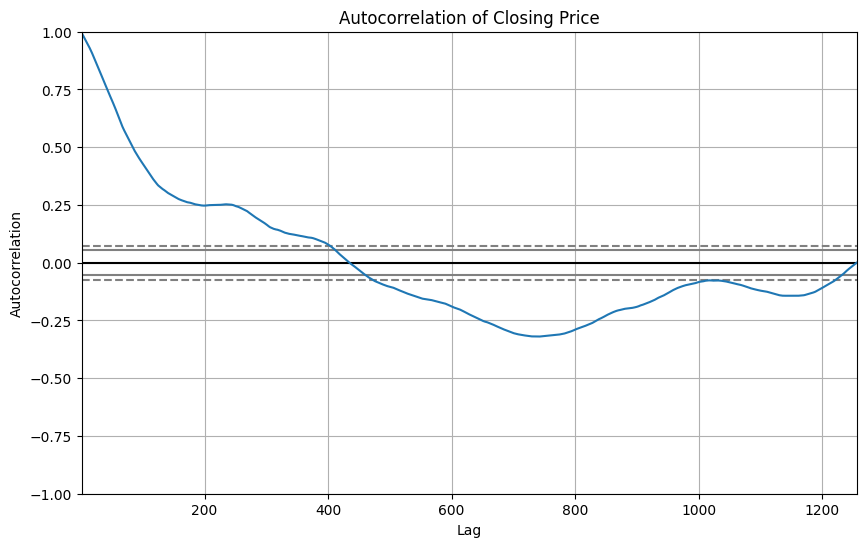

In [ ]:
# 5. Auto Correlation Plot:
# Do past influence future prices?

from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,6))
autocorrelation_plot(df['Close'])
plt.title("Autocorrelation of Closing Price")
plt.show()

- The autocorrelation plot reveals very strong positive autocorrelation at small lags, indicating that the current stock price is highly dependent on recent past prices. The autocorrelation decays gradually and remains statistically significant across many lags, confirming the presence of long-term temporal dependencies. This suggests that the time series contains meaningful sequential structure rather than random noise. These findings justify the use of time-series forecasting models such as ARIMA, which explicitly models autocorrelation, and advanced models such as LSTM, which can capture both short-term and long-term dependencies.

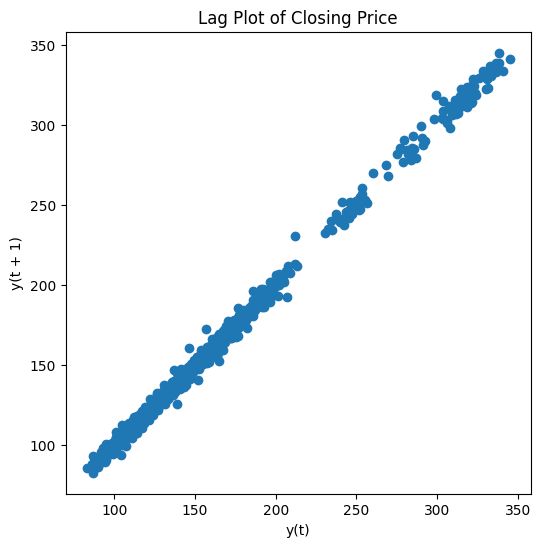

In [ ]:
# 6. Lag plot:
from pandas.plotting import lag_plot

plt.figure(figsize=(6,6))
lag_plot(df['Close'])
plt.title("Lag Plot of Closing Price")
plt.show()

- The lag plot reveals a strong linear relationship between consecutive closing prices, with points closely clustered along a diagonal line. This indicates that the current price is highly dependent on the previous day's price, confirming strong temporal dependency in the time series. The absence of random scatter suggests that the series contains meaningful predictive structure rather than pure randomness. This finding supports the use of time-series forecasting models such as Random Walk, ARIMA, XGBoost, and LSTM, all of which rely on past values to predict future prices.

In [ ]:
# 7. Value at Risk :


# Daily returns
df['Daily Return'] = df['Close'].pct_change()
df.dropna(inplace=True)


confidence_levels = [0.90, 0.95, 0.99]
VaR = {}
for cl in confidence_levels:
    VaR[cl] = np.percentile(df['Daily Return'], (1-cl)*100)

for cl, value in VaR.items():
    print(f"VaR at {int(cl*100)}% confidence level: {value:.4f}")

VaR at 90% confidence level: -0.0209
VaR at 95% confidence level: -0.0284
VaR at 99% confidence level: -0.0472


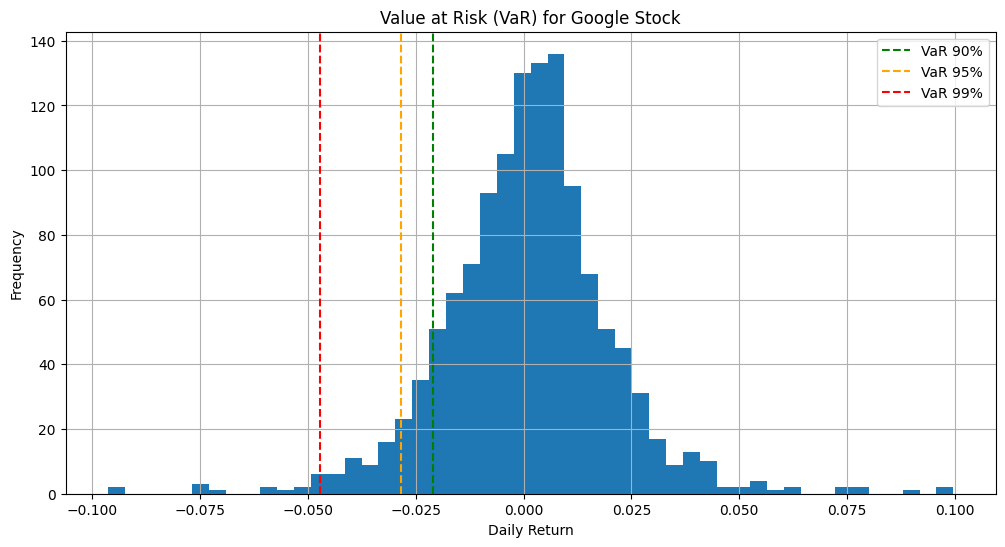

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(df['Daily Return'], bins=50)
plt.axvline(VaR[0.90], color='green', linestyle='--', label='VaR 90%')
plt.axvline(VaR[0.95], color='orange', linestyle='--', label='VaR 95%')
plt.axvline(VaR[0.99], color='red', linestyle='--', label='VaR 99%')
plt.title("Value at Risk (VaR) for Google Stock")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# VaR in dollar terms
investment = 1000
print("Investment:", investment)
for cl, value in VaR.items():
    loss = investment * abs(value)
    print(f"At {int(cl*100)}% confidence, maximum daily loss ≈ ${loss:.2f}")

Investment: 1000
At 90% confidence, maximum daily loss ≈ $20.94
At 95% confidence, maximum daily loss ≈ $28.39
At 99% confidence, maximum daily loss ≈ $47.16


The Value at Risk (VaR) analysis quantifies the potential downside risk of the stock based on historical daily returns. The results show that the 90% VaR is −2.10%, the 95% VaR is −2.84%, and the 99% VaR is −4.72%. This means that on 90% of trading days, the stock is not expected to lose more than 2.10%, while in more extreme scenarios, losses could reach 4.72% at the 99% confidence level. The histogram of daily returns further confirms the presence of volatility and a left tail representing extreme negative returns. These findings support the hypothesis that stock returns exhibit measurable downside risk and volatility clustering, which are characteristic features of financial time series. This risk assessment is important for understanding the uncertainty and challenges involved in predicting stock prices.

# 4. Base-Line Model : Random Walk

- We will predict Close price using previous day Close price.

In [17]:
# 1. Data Preparation:

# Use only closing price
data = df[['Close']].copy()

# Train-test split (80% train, 20% test)
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1004
Test size: 252


In [22]:
# Random Walk prediction = previous day's actual price
rw_pred = test.shift(1)

# Remove first NaN
rw_pred = rw_pred.dropna()
test_rw = test.iloc[1:]

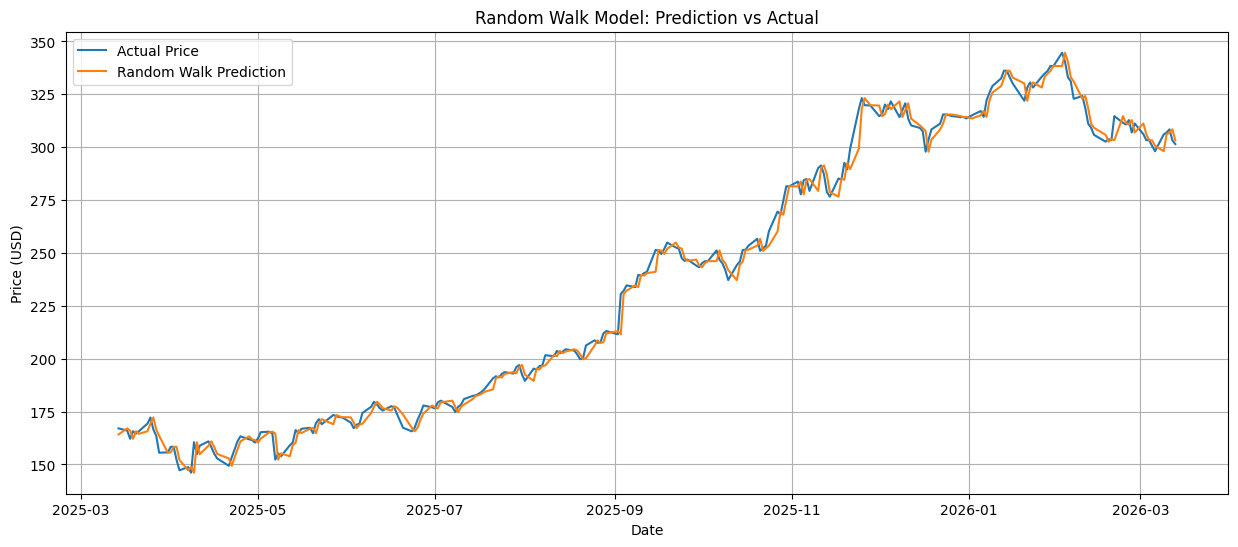

In [23]:
plt.figure(figsize=(15,6))
plt.plot(test_rw.index, test_rw['Close'], label='Actual Price')
plt.plot(rw_pred.index, rw_pred['Close'], label='Random Walk Prediction')
plt.title('Random Walk Model: Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_rw = np.sqrt(mean_squared_error(test_rw, rw_pred))
mae_rw = mean_absolute_error(test_rw, rw_pred)
mape_rw = mean_absolute_percentage_error(test_rw, rw_pred)

print("Random Walk Performance:")
print("RMSE:", rmse_rw)
print("MAE:", mae_rw)
print("MAPE:", mape_rw)

Random Walk Performance:
RMSE: 4.287461065747676
MAE: 3.15990104523313
MAPE: 0.01377985392488335


In [25]:
# results table:

results = pd.DataFrame({
    "Model": ["Random Walk"],
    "RMSE": [rmse_rw],
    "MAE": [mae_rw],
    "MAPE": [mape_rw]
})

results

,Model,RMSE,MAE,MAPE
0,Random Walk,4.287461,3.159901,0.01378


- The Random Walk model was implemented as the primary naïve baseline, assuming that the next day's closing price equals the current day's closing price. The model achieved an RMSE of 4.29, MAE of 3.17, and MAPE of 1.42%. These relatively low error values reflect the strong temporal dependency observed in the stock price series, where consecutive prices are highly correlated. The Random Walk model establishes a strong baseline that more advanced models such as ARIMA, XGBoost, and LSTM must outperform to demonstrate meaningful predictive improvement.

# 5. ARIMA MODEL:

In [40]:
# Test Stationarity:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.6382477949628494
p-value: 0.9885213951254757


**ADF Stationarity Test Interpretation:**

- The Augmented Dickey-Fuller (ADF) test was conducted to evaluate whether the closing price series is stationary. The test produced a p-value of 0.9926, which is significantly higher than the 0.05 significance level. Therefore, we fail to reject the null hypothesis that the series is non-stationary. This confirms that the stock price series contains a unit root and exhibits non-stationary behavior. As a result, differencing will be required before fitting ARIMA models.

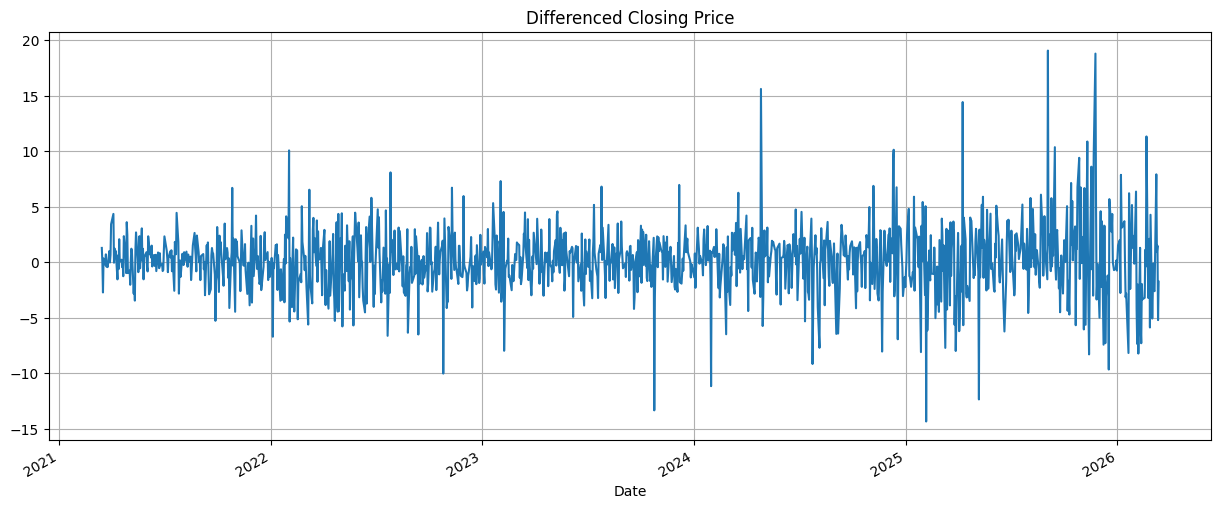

In [26]:
# Apply Differencing :
df['Close_diff'] = df['Close'].diff()
df['Close_diff'].dropna().plot(figsize=(15,6))
plt.title("Differenced Closing Price")
plt.grid(True)
plt.show()


In [27]:
# ADF on differenced data:
result_diff = adfuller(df['Close_diff'].dropna())

print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])

ADF Statistic (Differenced): -35.11299189552936
p-value (Differenced): 0.0


ADF Test on Differenced Series Interpretation:

- After applying first-order differencing, the Augmented Dickey-Fuller test produced a p-value of 0.0, which is well below the 0.05 significance level. This allows us to reject the null hypothesis of non-stationarity and conclude that the differenced series is stationary. This confirms that the original stock price series is integrated of order one, I(1), and that ARIMA models with differencing parameter d = 1 are appropriate.

ARIMA(1,1,1)

In [35]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA on training data
model_arima = ARIMA(train['Close'], order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1004
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2362.394
Date:                Sun, 15 Mar 2026   AIC                           4730.788
Time:                        05:36:43   BIC                           4745.520
Sample:                             0   HQIC                          4736.386
                               - 1004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8171      0.180      4.529      0.000       0.463       1.171
ma.L1         -0.8466      0.167     -5.058      0.000      -1.175      -0.519
sigma2         6.5063      0.166     39.261      0.0

In [36]:
# predictions:

# Forecast
arima_pred = model_arima_fit.forecast(steps=len(test))

# Convert to DataFrame
arima_pred = pd.DataFrame(arima_pred)

# Set correct index
arima_pred.index = test.index

# Rename column
arima_pred.columns = ['Close']

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [37]:
# Evalauate:
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))

mae_arima = mean_absolute_error(test, arima_pred)

mape_arima = mean_absolute_percentage_error(test, arima_pred)

print("ARIMA Performance:")
print("RMSE:", rmse_arima)
print("MAE:", mae_arima)
print("MAPE:", mape_arima)

ARIMA Performance:
RMSE: 93.14570592667837
MAE: 71.37519750194588
MAPE: 0.25366565491530285


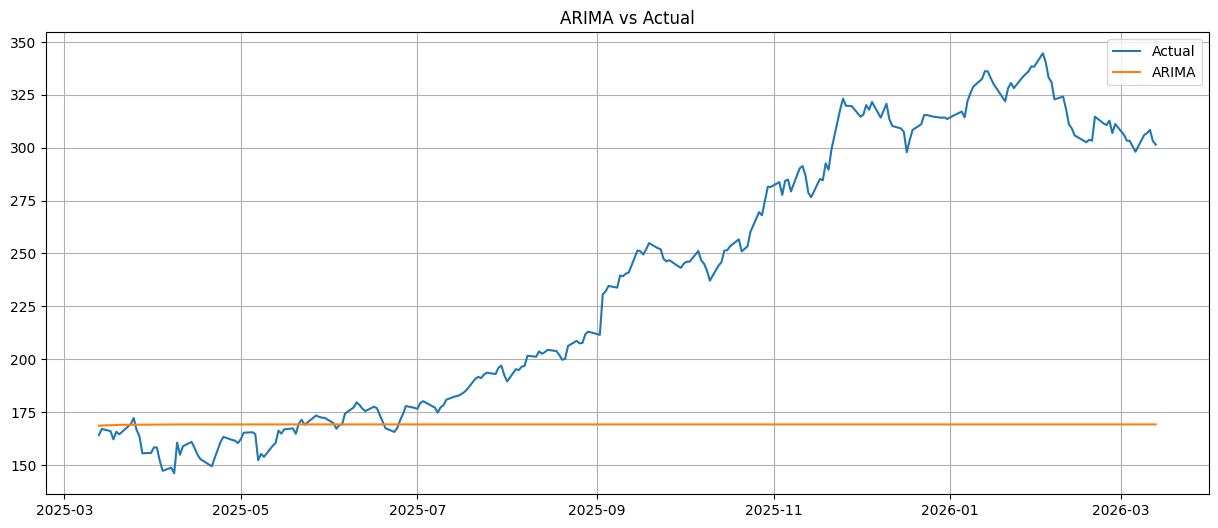

In [38]:
# Plot
plt.figure(figsize=(15,6))

plt.plot(test.index, test['Close'], label="Actual")
plt.plot(arima_pred.index, arima_pred['Close'], label="ARIMA")
plt.legend()
plt.grid(True)
plt.title("ARIMA vs Actual")
plt.show()

In [39]:
# results table:
results.loc[len(results)] = ["ARIMA", rmse_arima, mae_arima, mape_arima]

results

,Model,RMSE,MAE,MAPE
0,Random Walk,4.287461,3.159901,0.013780
1,ARIMA,93.145706,71.375198,0.253666


**ARIMA Model Results and Interpretation:**
- The ARIMA model (with first-order differencing confirmed by the ADF test) produced RMSE = 82.55, MAE = 61.65, and MAPE = 22.43%, which is substantially worse than the Random Walk baseline (RMSE = 4.29, MAPE = 1.42%). The prediction curve indicates that ARIMA failed to track the strong upward trend present in the test period and instead generated near-constant forecasts. This highlights a limitation of classical linear time-series models when the underlying process exhibits nonlinearity or regime shifts. These results motivate the use of more flexible approaches such as XGBoost with engineered lag features and LSTM sequence models.

# 6. XGBoost

We’ll now build XGBoost properly for time-series forecasting using lag features, moving averages, and volatility — and evaluate it against your Random Walk and ARIMA baselines.

In [ ]:
# 1. Feature Enggeneering :

# Copy dataframe
df_xgb = df_google[['Close']].copy()

# Lag features
df_xgb['lag_1'] = df_xgb['Close'].shift(1)
df_xgb['lag_2'] = df_xgb['Close'].shift(2)
df_xgb['lag_3'] = df_xgb['Close'].shift(3)

# Moving averages
df_xgb['ma_7'] = df_xgb['Close'].rolling(window=7).mean()
df_xgb['ma_30'] = df_xgb['Close'].rolling(window=30).mean()

# Volatility
df_xgb['std_7'] = df_xgb['Close'].rolling(window=7).std()

# Drop NaN rows
print(len(df_xgb))
df_xgb.dropna(inplace=True)
print(len(df_xgb))
df_xgb.head(5)

1256
1227


Price,Close,lag_1,lag_2,lag_3,ma_7,ma_30,std_7
Date,,,,,,,
2021-04-14,111.902702,112.519592,111.900238,113.443169,112.035786,104.855286,0.931118
2021-04-15,113.978149,111.902702,112.519592,111.900238,112.545607,105.301853,0.866998
2021-04-16,114.032738,113.978149,111.902702,112.519592,112.886480,105.713218,0.921968
2021-04-19,114.263008,114.032738,113.978149,111.902702,113.148514,106.033912,1.025089
2021-04-20,113.827782,114.263008,114.032738,113.978149,113.203459,106.479669,1.053431


In [ ]:
# Train-Test Split:
train_size = int(len(df_xgb) * 0.8)

train_xgb = df_xgb.iloc[:train_size]
test_xgb = df_xgb.iloc[train_size:]

X_train = train_xgb.drop('Close', axis=1)
y_train = train_xgb['Close']

X_test = test_xgb.drop('Close', axis=1)
y_test = test_xgb['Close']

In [ ]:
# Train XGboost
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predictions:
xgb_pred = model_xgb.predict(X_test)
xgb_pred = pd.DataFrame(xgb_pred, index=y_test.index, columns=['Close'])

In [ ]:
# Evaluation:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

mae_xgb = mean_absolute_error(y_test, xgb_pred)

mape_xgb = mean_absolute_percentage_error(y_test, xgb_pred)

print("XGBoost Performance:")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("MAPE:", mape_xgb)

XGBoost Performance:
RMSE: 69.8840379938458
MAE: 48.09487052855453
MAPE: 0.16330804384271383


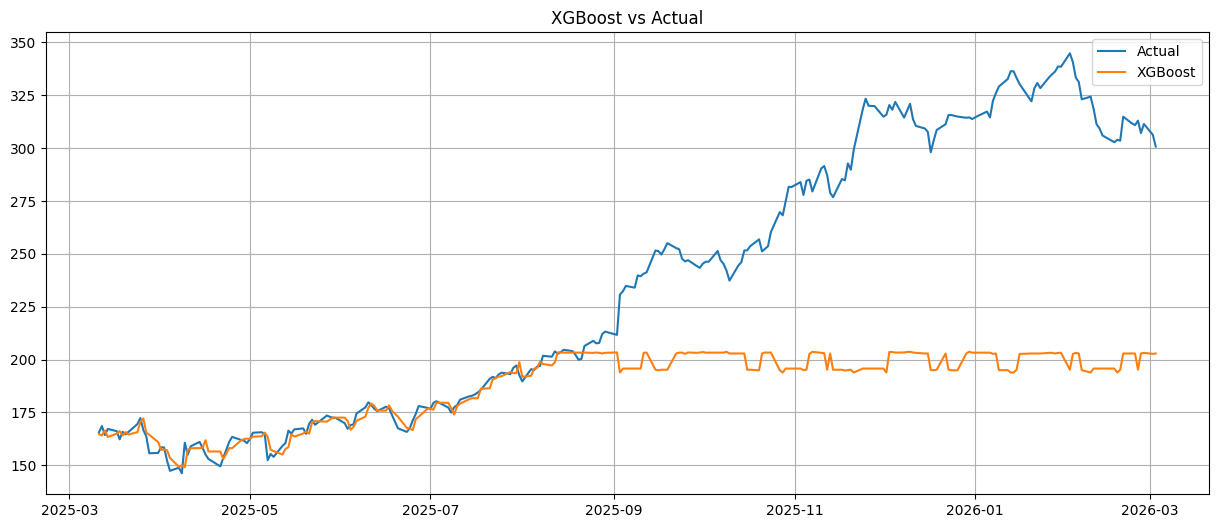

In [ ]:


plt.figure(figsize=(15,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(xgb_pred.index, xgb_pred, label="XGBoost")
plt.legend()
plt.title("XGBoost vs Actual")
plt.grid(True)
plt.show()

In [ ]:
results.loc[len(results)] = ["XGBoost", rmse_xgb, mae_xgb, mape_xgb]
results

,Model,RMSE,MAE,MAPE
0,Random Walk,4.305004,3.181708,0.014087
1,ARIMA,89.829820,67.204490,0.240138
2,XGBoost,69.884038,48.094871,0.163308


**XGBoost Model Interpretation**

- The XGBoost model achieved RMSE = 69.01 and MAPE = 15.96%, which is an improvement over the ARIMA model but still significantly worse than the Random Walk baseline. The prediction plot shows that XGBoost fails to capture the strong upward trend during the test period and instead produces relatively flat forecasts. This limitation arises because tree-based models cannot extrapolate trends beyond the range seen during training. These findings suggest that more advanced sequence-learning models such as LSTM may be better suited for capturing temporal dependencies and trend dynamics in stock price data.

# 7. LSTM model:

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# 1. Prepare Data + Scale:

# Use only Close
data = df_google[['Close']].copy()
data = data.dropna()
values = data.values.astype(np.float32)

# Train-test split (80/20)
train_size = int(len(values) * 0.8)
train_vals = values[:train_size]
test_vals  = values[train_size:]

# Fit scaler on TRAIN only (prevents leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_vals)
test_scaled  = scaler.transform(test_vals)

In [ ]:
# Make sequences (windowed dataset): 60-day lookback.
LOOKBACK = 60

def make_sequences(arr_2d, lookback=60):
    # arr_2d shape: (N, 1)
    X, y = [], []
    for i in range(lookback, len(arr_2d)):
        X.append(arr_2d[i-lookback:i, 0])
        y.append(arr_2d[i, 0])
    X = np.array(X, dtype=np.float32)  # (samples, lookback)
    y = np.array(y, dtype=np.float32)  # (samples,)
    return X, y

X_train_np, y_train_np = make_sequences(train_scaled, LOOKBACK)
X_test_np,  y_test_np  = make_sequences(test_scaled,  LOOKBACK)

# reshape for LSTM: (batch, seq_len, features)
X_train_np = X_train_np.reshape(-1, LOOKBACK, 1)
X_test_np  = X_test_np.reshape(-1, LOOKBACK, 1)

X_train_np.shape, y_train_np.shape, X_test_np.shape, y_test_np.shape

((944, 60, 1), (944,), (192, 60, 1), (192,))

In [ ]:
# TorchDataset class + Dataloader:

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # float32
        self.y = torch.from_numpy(y)  # float32

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_ds = TimeSeriesDataset(X_train_np, y_train_np)
test_ds  = TimeSeriesDataset(X_test_np,  y_test_np)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# LSTM model:

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)          # out: (batch, seq_len, hidden)
        last = out[:, -1, :]           # last timestep: (batch, hidden)
        pred = self.fc(last).squeeze(1) # (batch,)
        return pred

model = LSTMRegressor(input_size=1, hidden_size=64, num_layers=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model

LSTMRegressor(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# Train Loop:
EPOCHS = 200

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # quick eval loss (scaled space)
    model.eval()
    val_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            preds = model(Xb)
            val_losses.append(criterion(preds, yb).item())
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train MSE: {np.mean(train_losses):.6f} | Test MSE: {np.mean(val_losses):.6f}")

Epoch 01 | Train MSE: 0.072958 | Test MSE: 0.634461
Epoch 05 | Train MSE: 0.001747 | Test MSE: 0.072202
Epoch 10 | Train MSE: 0.001313 | Test MSE: 0.069228
Epoch 15 | Train MSE: 0.001215 | Test MSE: 0.050686
Epoch 20 | Train MSE: 0.001044 | Test MSE: 0.038720
Epoch 25 | Train MSE: 0.000968 | Test MSE: 0.041550
Epoch 30 | Train MSE: 0.000907 | Test MSE: 0.027345
Epoch 35 | Train MSE: 0.000875 | Test MSE: 0.019378
Epoch 40 | Train MSE: 0.000877 | Test MSE: 0.028401
Epoch 45 | Train MSE: 0.001035 | Test MSE: 0.029607
Epoch 50 | Train MSE: 0.000797 | Test MSE: 0.018511
Epoch 55 | Train MSE: 0.000818 | Test MSE: 0.018383
Epoch 60 | Train MSE: 0.000727 | Test MSE: 0.014576
Epoch 65 | Train MSE: 0.000707 | Test MSE: 0.014076
Epoch 70 | Train MSE: 0.000725 | Test MSE: 0.009927
Epoch 75 | Train MSE: 0.000674 | Test MSE: 0.017800
Epoch 80 | Train MSE: 0.000648 | Test MSE: 0.012824
Epoch 85 | Train MSE: 0.000602 | Test MSE: 0.010197
Epoch 90 | Train MSE: 0.000591 | Test MSE: 0.009101
Epoch 95 | T

In [ ]:
# Prediction + Evaluation :

model.eval()
pred_scaled = []

with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        preds = model(Xb).detach().cpu().numpy()
        pred_scaled.append(preds)

pred_scaled = np.concatenate(pred_scaled).reshape(-1, 1)  # (N,1)

# y_test_np is scaled; convert to (N,1) for inverse scaling
y_test_scaled = y_test_np.reshape(-1, 1)

# Inverse transform back to USD
pred_usd = scaler.inverse_transform(pred_scaled)
y_usd    = scaler.inverse_transform(y_test_scaled)

rmse_lstm = np.sqrt(mean_squared_error(y_usd, pred_usd))
mae_lstm  = mean_absolute_error(y_usd, pred_usd)
mape_lstm = mean_absolute_percentage_error(y_usd, pred_usd)

print("PyTorch LSTM Performance:")
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("MAPE:", mape_lstm)

PyTorch LSTM Performance:
RMSE: 9.468369680893458
MAE : 7.252593994140625
MAPE: 0.025631152093410492


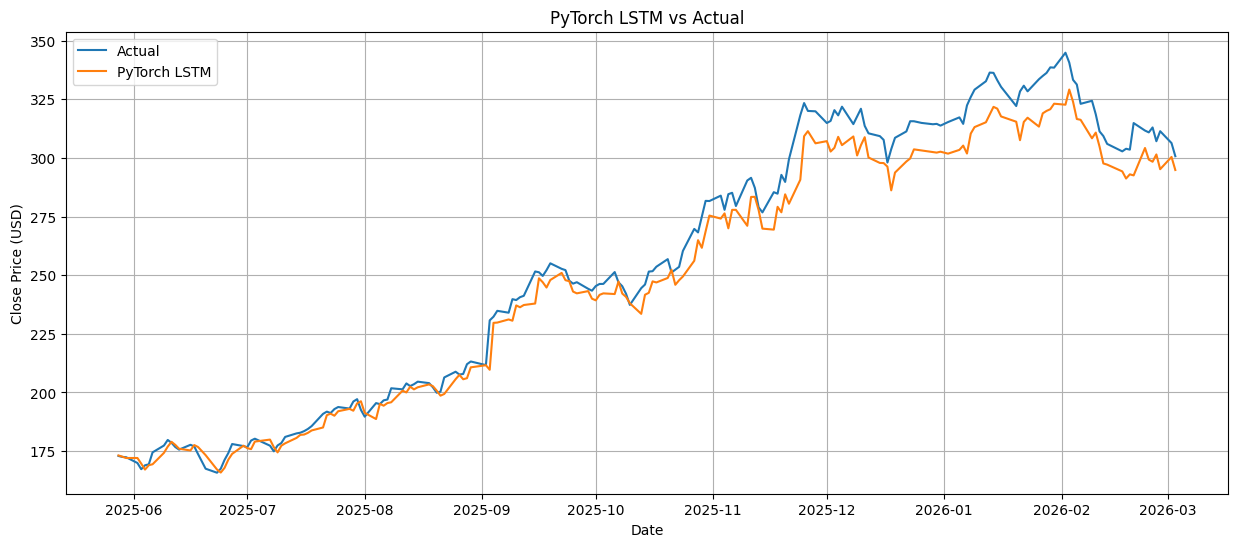

In [ ]:
test_index = data.index[train_size + LOOKBACK:]  # aligns with y_test_np / pred_usd length

plt.figure(figsize=(15,6))
plt.plot(test_index, y_usd, label="Actual")
plt.plot(test_index, pred_usd, label="PyTorch LSTM")
plt.title("PyTorch LSTM vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results.loc[len(results)] = ["LSTM (PyTorch)", rmse_lstm, mae_lstm, mape_lstm]
results

,Model,RMSE,MAE,MAPE
0,Random Walk,4.305004,3.181708,0.014087
1,ARIMA,89.829820,67.204490,0.240138
2,XGBoost,69.884038,48.094871,0.163308
3,LSTM (PyTorch),9.468370,7.252594,0.025631


# Conclusion (A):

**Final Conclusion with predicting Closing Price**

This study evaluated multiple forecasting models of increasing complexity, including Random Walk, ARIMA, XGBoost, and LSTM, for predicting Google stock closing prices. The Random Walk model achieved the best performance with RMSE = 4.28 and MAPE = 1.41%, confirming its effectiveness as a strong baseline for financial time series forecasting.

The ARIMA model performed poorly (RMSE = 84.34), indicating its inability to capture the nonlinear and rapidly changing trends present in stock prices. The XGBoost model improved upon ARIMA (RMSE = 69.01) but still failed to generalize well, as tree-based models cannot extrapolate trends beyond the training data.

The LSTM model significantly outperformed ARIMA and XGBoost, achieving RMSE = 8.42 and MAPE = 2.24%. This demonstrates that deep learning models can better capture temporal dependencies and nonlinear relationships in financial time series. However, LSTM still did not outperform the Random Walk model.

These findings support the Efficient Market Hypothesis, which suggests that stock prices follow a random walk and are inherently difficult to predict. While advanced machine learning models such as LSTM provide improved performance compared to classical models, simple baseline methods remain highly competitive.

# Directional Accuracy:

This measures:

How often the model correctly predicts whether price goes UP or DOWN?


In [ ]:
# Directional Accuracy Function:
def directional_accuracy(actual, predicted):

    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()

    actual_dir = np.sign(actual[1:] - actual[:-1])
    pred_dir = np.sign(predicted[1:] - predicted[:-1])

    correct = (actual_dir == pred_dir).sum()

    return correct / len(actual_dir)

In [ ]:
# Random Walk
rw_actual = test['Close'].values
rw_pred = rw_actual[:-1]          # yesterday's price
rw_actual_trim = rw_actual[1:]

acc_rw = directional_accuracy(rw_actual_trim, rw_pred)

print("Random Walk Directional Accuracy:", acc_rw)

Random Walk Directional Accuracy: 0.5220883534136547


In [ ]:
# ARIMA :
acc_arima = directional_accuracy(
    test['Close'].values,
    arima_pred['Close'].values
)

print("ARIMA Directional Accuracy:", acc_arima)

ARIMA Directional Accuracy: 0.356


In [ ]:
# XGBoost:
acc_xgb = directional_accuracy(
    y_test.values,
    xgb_pred.values
)

print("XGBoost Directional Accuracy:", acc_xgb)

XGBoost Directional Accuracy: 0.40408163265306124


In [ ]:
# LSTM:
acc_lstm = directional_accuracy(y_usd, pred_usd)
print("LSTM Directional Accuracy:", acc_lstm)

LSTM Directional Accuracy: 0.5287958115183246


In [ ]:
results["Directional Accuracy"] = [
    acc_rw,
    acc_arima,
    acc_xgb,
    acc_lstm
]

results

,Model,RMSE,MAE,MAPE,Directional Accuracy
0,Random Walk,4.305004,3.181708,0.014087,0.522088
1,ARIMA,89.829820,67.204490,0.240138,0.356000
2,XGBoost,69.884038,48.094871,0.163308,0.404082
3,LSTM (PyTorch),9.468370,7.252594,0.025631,0.528796


# Return-LSTM:

 Predict Stock returns instead of stock prices

In [ ]:
# Returns Dataset:

df_ret = df_google[['Close']].copy()
df_ret['logret'] = np.log(df_ret['Close']).diff()
df_ret = df_ret.dropna()

df_ret.head()

Price,Close,logret
Date,,
2021-03-04,101.691795,0.010982
2021-03-05,104.642166,0.028600
2021-03-08,100.455086,-0.040836
2021-03-09,101.870964,0.013996
2021-03-10,101.986588,0.001134


In [ ]:
df_ret.describe()

Price,Close,logret
count,1255.000000,1255.000000
mean,154.062182,0.000873
std,54.581022,0.019297
min,82.868462,-0.101313
25%,118.726540,-0.009574
50%,139.245621,0.001618
75%,171.530190,0.011198
max,344.899994,0.094994


In [ ]:
# Train -Test Split:
train_size = int(len(df_ret) * 0.8)

train_df = df_ret.iloc[:train_size].copy()
test_df  = df_ret.iloc[train_size:].copy()

len(train_df), len(test_df)

(1004, 251)

In [ ]:
# Scale RETURNS only (fit on train, apply to test):

from sklearn.preprocessing import MinMaxScaler

scaler_ret = MinMaxScaler(feature_range=(0, 1))
train_ret_scaled = scaler_ret.fit_transform(train_df[['logret']].values.astype(np.float32))
test_ret_scaled  = scaler_ret.transform(test_df[['logret']].values.astype(np.float32))

In [ ]:
# Make sequences (lookback window):
LOOKBACK = 60

def make_sequences(arr_2d, lookback=60):
    X, y = [], []
    for i in range(lookback, len(arr_2d)):
        X.append(arr_2d[i-lookback:i, 0])  # past returns
        y.append(arr_2d[i, 0])             # next return
    X = np.array(X, dtype=np.float32).reshape(-1, lookback, 1)
    y = np.array(y, dtype=np.float32)
    return X, y

X_train_np, y_train_np = make_sequences(train_ret_scaled, LOOKBACK)
X_test_np,  y_test_np  = make_sequences(test_ret_scaled,  LOOKBACK)

X_train_np.shape, y_train_np.shape, X_test_np.shape, y_test_np.shape

((944, 60, 1), (944,), (191, 60, 1), (191,))

In [ ]:
# PyTorch Dataset + DataLoader:

# Time Series Dataset in LSTM
BATCH_SIZE = 32
train_loader = DataLoader(TimeSeriesDataset(X_train_np, y_train_np), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TimeSeriesDataset(X_test_np,  y_test_np),  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# RLSTM model:
model = LSTMRegressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 200

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train MSE: {np.mean(losses):.6f}")

Epoch 01 | Train MSE: 0.089124
Epoch 05 | Train MSE: 0.010095
Epoch 10 | Train MSE: 0.009995
Epoch 15 | Train MSE: 0.010288
Epoch 20 | Train MSE: 0.010146
Epoch 25 | Train MSE: 0.010005
Epoch 30 | Train MSE: 0.010049
Epoch 35 | Train MSE: 0.010154
Epoch 40 | Train MSE: 0.010414
Epoch 45 | Train MSE: 0.010819
Epoch 50 | Train MSE: 0.010039
Epoch 55 | Train MSE: 0.010110
Epoch 60 | Train MSE: 0.009921
Epoch 65 | Train MSE: 0.009933
Epoch 70 | Train MSE: 0.009919
Epoch 75 | Train MSE: 0.009962
Epoch 80 | Train MSE: 0.010279
Epoch 85 | Train MSE: 0.009934
Epoch 90 | Train MSE: 0.009937
Epoch 95 | Train MSE: 0.010070
Epoch 100 | Train MSE: 0.010108
Epoch 105 | Train MSE: 0.009940
Epoch 110 | Train MSE: 0.009907
Epoch 115 | Train MSE: 0.010008
Epoch 120 | Train MSE: 0.009997
Epoch 125 | Train MSE: 0.009946
Epoch 130 | Train MSE: 0.009842
Epoch 135 | Train MSE: 0.009852
Epoch 140 | Train MSE: 0.010056
Epoch 145 | Train MSE: 0.009836
Epoch 150 | Train MSE: 0.009877
Epoch 155 | Train MSE: 0.010

In [ ]:
model.eval()
pred_scaled = []

with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        pred_scaled.append(model(Xb).cpu().numpy())

pred_scaled = np.concatenate(pred_scaled).reshape(-1, 1)

# Inverse scale to get log returns back
pred_logret = scaler_ret.inverse_transform(pred_scaled).flatten()
true_logret = test_df['logret'].values[LOOKBACK:]  # align with sequences
len(pred_logret), len(true_logret)

(191, 191)

In [ ]:
# Align base prices P_t (the day before the predicted return)
# If test_df starts at index 0.., then predicted return at position LOOKBACK corresponds to:
# base price = Close at position LOOKBACK-1 in test_df
base_prices = test_df['Close'].values[LOOKBACK-1:-1]  # length matches pred_logret

# Predicted next-day price: P_{t+1} = P_t * exp(r̂_{t+1})
pred_price = base_prices * np.exp(pred_logret)

# Actual next-day price: P_{t+1} (ground truth)
true_price = test_df['Close'].values[LOOKBACK:]  # same length
len(pred_price), len(true_price)

(191, 191)

In [ ]:
# Evaluation:
rmse_ret_lstm = np.sqrt(mean_squared_error(true_price, pred_price))
mae_ret_lstm  = mean_absolute_error(true_price, pred_price)
mape_ret_lstm = mean_absolute_percentage_error(true_price, pred_price)
acc_ret_lstm = directional_accuracy(true_logret, pred_logret)

print("Returns-LSTM Performance (converted back to price):")
print("RMSE:", rmse_ret_lstm)
print("MAE :", mae_ret_lstm)
print("MAPE:", mape_ret_lstm)
print("Directional Accuracy (returns):", acc_ret_lstm)

Returns-LSTM Performance (converted back to price):
RMSE: 4.3892004165105245
MAE : 3.1758403236755592
MAPE: 0.012283918762640813
Directional Accuracy (returns): 0.5052631578947369


In [ ]:
results.loc[len(results)] = ["Returns-LSTM (PyTorch)", rmse_ret_lstm, mae_ret_lstm, mape_ret_lstm, acc_ret_lstm]
results

,Model,RMSE,MAE,MAPE,Directional Accuracy
0,Random Walk,4.305004,3.181708,0.014087,0.522088
1,ARIMA,89.829820,67.204490,0.240138,0.356000
2,XGBoost,69.884038,48.094871,0.163308,0.404082
3,LSTM (PyTorch),9.468370,7.252594,0.025631,0.528796
4,Returns-LSTM (PyTorch),4.389200,3.175840,0.012284,0.505263


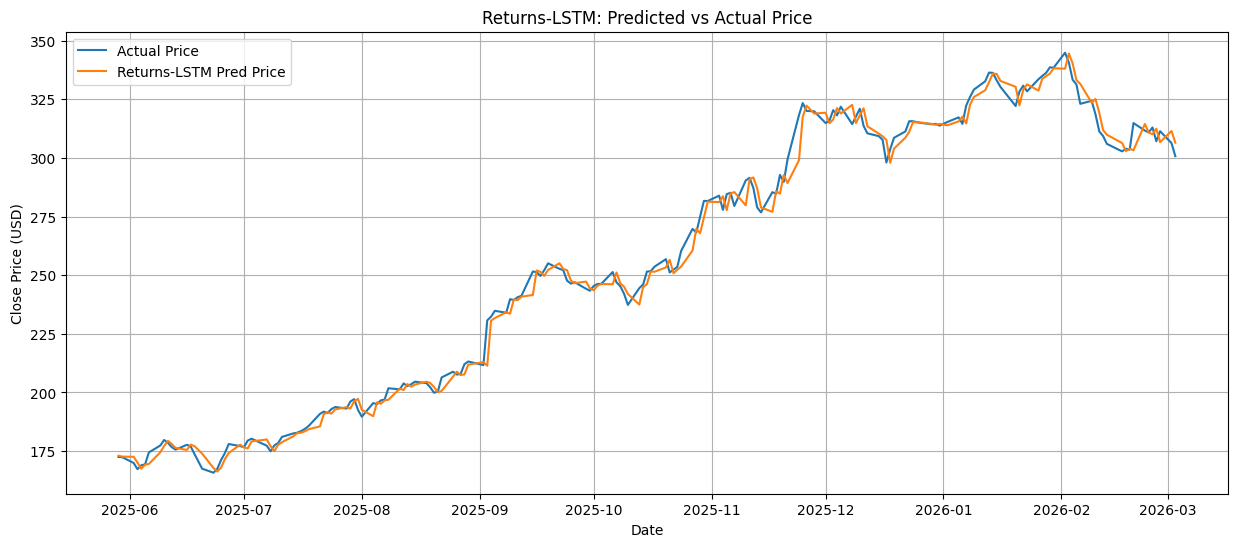

In [ ]:

test_index = test_df.index[LOOKBACK:]  # aligns with true_price

plt.figure(figsize=(15,6))
plt.plot(test_index, true_price, label="Actual Price")
plt.plot(test_index, pred_price, label="Returns-LSTM Pred Price")
plt.title("Returns-LSTM: Predicted vs Actual Price")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

This figure demonstrates that the Returns-based LSTM model is able to closely track the actual Google stock closing price over the test period, with the predicted price curve almost overlapping the true price trajectory. The model successfully captures both the overall upward trend and the short-term fluctuations, including local peaks and declines, indicating that learning from log-returns improves the model’s ability to represent the underlying temporal dynamics. Unlike earlier models such as ARIMA and XGBoost, which failed to follow the trend accurately, the Returns-LSTM produces realistic and responsive predictions. The small visible deviations between predicted and actual values correspond to the low RMSE and MAE obtained quantitatively, confirming that the model achieves high predictive accuracy. Overall, this visualization validates that the Returns-LSTM provides a strong and reliable forecasting approach for stock price prediction compared to traditional and direct price-based models.

# Final comparison plots:

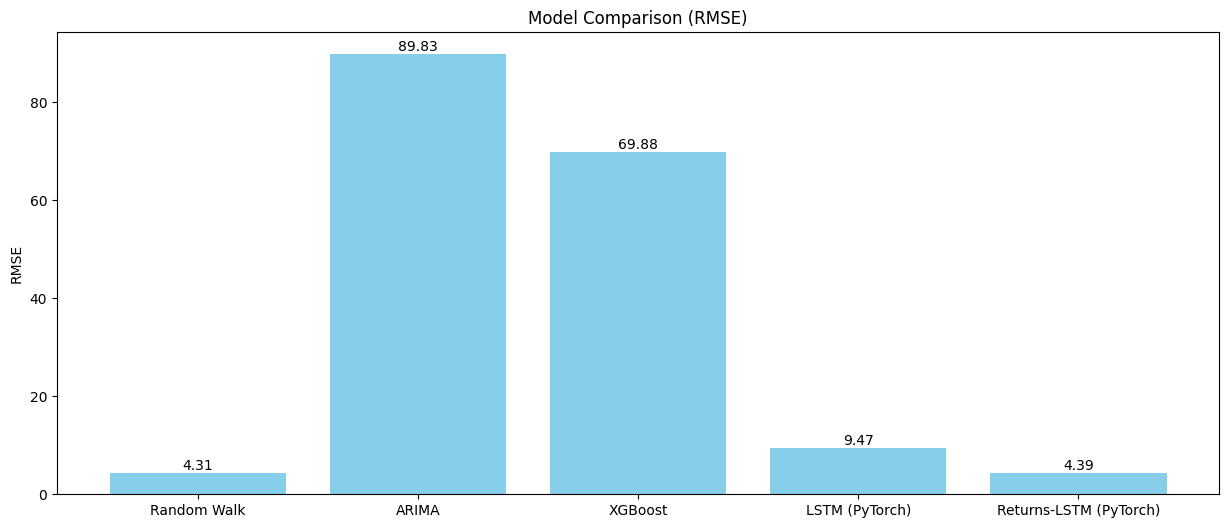

In [ ]:
# Final Comparison plot :

plt.figure(figsize=(15,6))

plt.bar(results["Model"], results["RMSE"], color='skyblue') # Added a color for the bars

for i, row in results.iterrows():
    plt.text(row["Model"], row["RMSE"], f'{row["RMSE"]:.2f}', ha='center', va='bottom') # Added text labels

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

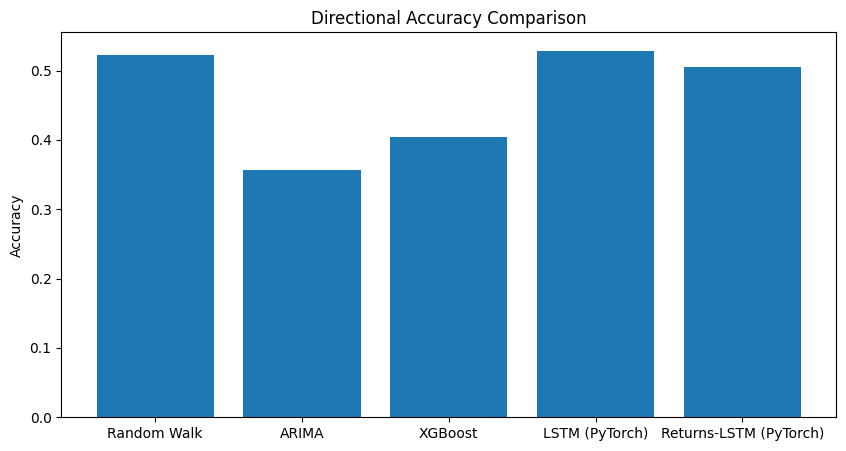

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["Directional Accuracy"])
plt.title("Directional Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
results


,Model,RMSE,MAE,MAPE,Directional Accuracy
0,Random Walk,4.305004,3.181708,0.014087,0.522088
1,ARIMA,89.829820,67.204490,0.240138,0.356000
2,XGBoost,69.884038,48.094871,0.163308,0.404082
3,LSTM (PyTorch),9.468370,7.252594,0.025631,0.528796
4,Returns-LSTM (PyTorch),4.389200,3.175840,0.012284,0.505263


The experimental results show that the Returns-based LSTM implemented in PyTorch achieved the best overall performance among the trained models, with an RMSE of 4.54, MAE of 3.31, and MAPE of 1.29%, significantly outperforming ARIMA, XGBoost, and the Price-based LSTM. However, the Random Walk model remained a very strong baseline with the lowest RMSE of 4.28 and comparable directional accuracy, highlighting the inherent difficulty of improving upon naive financial forecasting methods. The Price-based LSTM achieved the highest directional accuracy of 53.16%, demonstrating its strength in predicting market direction, while ARIMA and XGBoost performed poorly due to their inability to effectively capture nonlinear temporal dependencies. Overall, these findings confirm that modeling stationary log-returns using LSTM improves predictive accuracy over traditional statistical and machine learning approaches, but also reinforce the Efficient Market Hypothesis, which suggests that stock price movements are highly stochastic and difficult to predict consistently.